<a href="https://colab.research.google.com/github/deburg0/Autoencoder/blob/main/Keras_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras import optimizers
from keras.optimizers import Adam

Load Data


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
np.shape(x_train), np.shape(y_train), np.shape(x_test), np.shape(y_test)

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
28*28

784

In [5]:
train_x = x_train.reshape(60000, 784)/255
val_x = x_test.reshape(10000,784)/255

In [6]:
input_img = Input(shape=(784,))
# Encoder
encoded = Dense(512, activation='elu')(input_img)
encoded = Dense(128, activation='elu')(encoded)
bottleneck = Dense(10, activation='linear', name="bottleneck")(encoded)
# Decoder
decoded = Dense(128, activation='elu')(bottleneck)
decoded = Dense(512, activation='elu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(loss='mean_squared_error', optimizer=Adam())

In [8]:
trained_model = autoencoder.fit(train_x, train_x, batch_size=1000, epochs=10, verbose=1, validation_data=(val_x, val_x))

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0187 - val_loss: 0.0182
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0182 - val_loss: 0.0177
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0177 - val_loss: 0.0173
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0173 - val_loss: 0.0170
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0169 - val_loss: 0.0166
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0166 - val_loss: 0.0164
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0163 - val_loss: 0.0160
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0161 - val_loss: 0.0158
Epoch 9/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0158 - val_loss: 0.0156
Epoch 10/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0156 - val_loss: 0.0154


In [9]:
encoder = Model(autoencoder.input, autoencoder.get_layer('bottleneck').output)

In [10]:
encoded_data = encoder.predict(train_x) # bottle_neck representation

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [11]:
decoded_output = autoencoder.predict(train_x) # reconstruction

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [12]:
encoding_dim = 10

In [13]:
# return the decoder
encoded_input = Input(shape=(encoding_dim,))
decoder = autoencoder.layers[-3](encoded_input)
decoder = autoencoder.layers[-2](decoder)
decoder = autoencoder.layers[-1](decoder)
decoder = Model(encoded_input, decoder)


In [23]:
x_test[6]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  22, 192, 134,  32,
          0,   0,   0,   0,   0,   0,   0,   0,  15,  77,   5,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  17, 235, 250, 169,   0,
          0,   0,   0,   0,   0,   0,   0,  15, 220, 241,  37,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  20, 189, 253, 147,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 139, 253, 100,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  70, 253, 253,  21,   0,   0,
          0,   0,   0,   0,   0,   0,  43, 254, 173,  13,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  22, 153, 253,  96,   0,   0,   0,
          0,   0,   0,   0,   0,  43, 231, 254,  92,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 163, 255, 204,  11,   0,   0,   0,
          0,   0,   0,   0,   0, 104, 254, 158,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 162, 253, 178,   5,   0,   0,   0,
          0,   0,   0,   9, 131, 237, 253,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 162, 253, 253, 191, 175,  70,  70,
         70,  70, 133, 197, 253, 253, 169,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  51, 228, 253, 253, 254, 253, 253,
        253, 253, 254, 253, 253, 219,  35,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  17,  65, 137, 254, 232, 137,
        137, 137,  44, 253, 253, 161,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  34, 254, 206,  21,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 160, 253,  69,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  85, 254, 241,  50,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 158, 254, 165,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 231, 244,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        104, 254, 232,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        208, 253, 157,   0,  13,  30,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        208, 253, 154,  91, 204, 161,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        208, 253, 254, 253, 154,  29,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [24]:
y_test[6]

np.uint8(4)

In [25]:
inputs = x_test[6].reshape(1,784)/255

In [26]:
target_data = autoencoder.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


In [27]:
target_img = target_data.reshape(28,28)


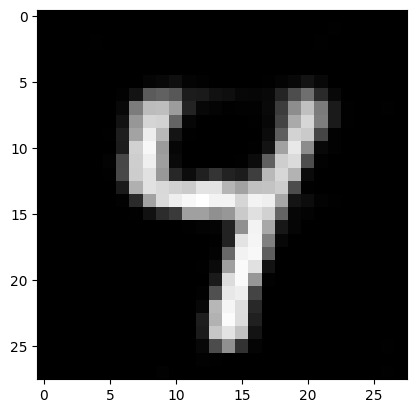

In [30]:
import matplotlib.pyplot as plt
plt.imshow(target_img, cmap='gray')
plt.show()

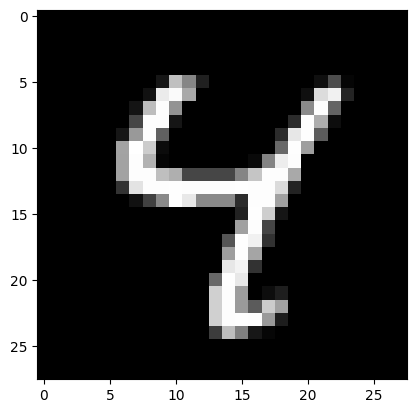

In [33]:
plt.imshow(val_x[6].reshape(28,28), cmap='gray')
plt.show()

In [31]:
dist = np.linalg.norm(inputs - target_data, axis=1)
print(dist)

[4.12148346]


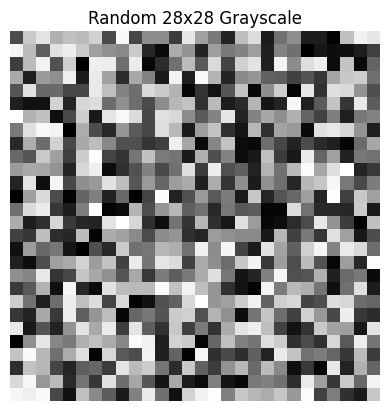

In [34]:
# Generate random float data
img_rand = np.random.rand(28, 28)

# Display as grayscale
plt.imshow(img_rand, cmap='gray')
plt.title("Random 28x28 Grayscale")
plt.axis('off') # Hide axes for cleaner image
plt.show()

In [36]:
inputs = img_rand.reshape(1,784)
target_data = autoencoder.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [37]:
dist = np.linalg.norm(inputs - target_data, axis=-1)
print(dist)


[14.13220115]


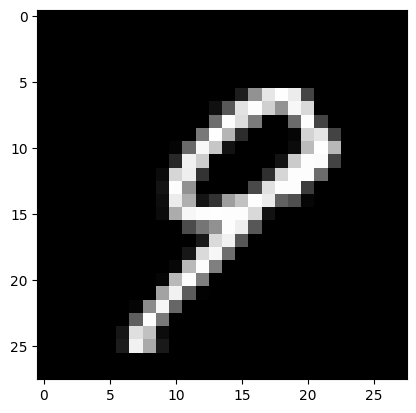

In [44]:
img = train_x[601].reshape(28,28)
plt.imshow(img, cmap='gray')
plt.show()

In [45]:
inputs = img.reshape(1,784)
cmp = encoder.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [46]:
cmp

array([[ 10.957725  ,  24.789318  ,  16.371365  , -10.453143  ,
         -1.4362454 ,   7.537687  ,  13.359775  ,   0.15834141,
        -12.8277025 ,  10.247586  ]], dtype=float32)

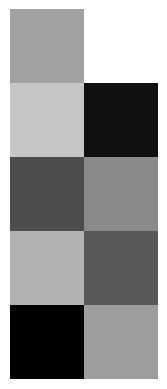

In [50]:
plt.imshow(cmp.reshape(5,2)/np.max(cmp), cmap='gray')
plt.axis('off') # Hide axes for cleaner image
plt.show()

In [52]:
output = decoder.predict(cmp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


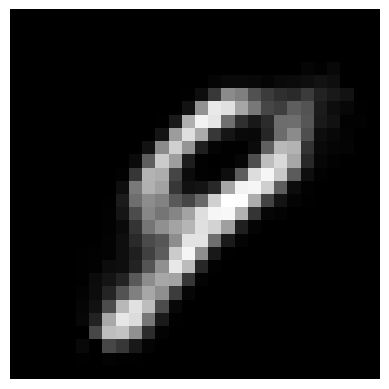

In [53]:
plt.imshow(output.reshape(28,28), cmap='gray')
plt.axis('off') # Hide axes for cleaner image
plt.show()

In [54]:
output = autoencoder.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


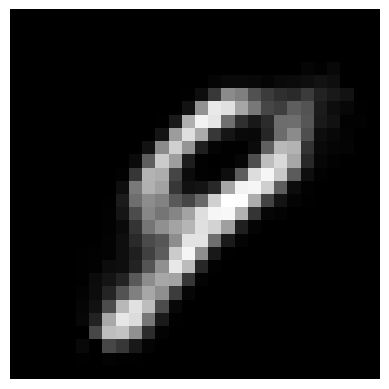

In [55]:
plt.imshow(output.reshape(28,28), cmap='gray')
plt.axis('off') # Hide axes for cleaner image
plt.show()